In [1]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, QuantumRegister,ClassicalRegister, transpile

from IPython.display import Math
from qc_workbook.show_state import statevector_expr

print("----Start----")
simulator = AerSimulator(method='statevector')
print(simulator.name)

----Start----
aer_simulator_statevector


In [2]:
from qiskit_aer.noise import NoiseModel
from qiskit_aer.noise.errors.standard_errors import pauli_error

model = NoiseModel()
error = pauli_error([("I",0.9),("X",0.05),("Z",0.05)])
model.add_all_qubit_quantum_error(error, ["id"])

print(error)

QuantumError on 1 qubits. Noise circuits:
  P(0) = 0.9, Circuit = 
   ┌───┐
q: ┤ I ├
   └───┘
  P(1) = 0.05, Circuit = 
   ┌───┐
q: ┤ X ├
   └───┘
  P(2) = 0.05, Circuit = 
   ┌───┐
q: ┤ Z ├
   └───┘


In [3]:
circuit = QuantumCircuit(9,1)

circuit.cx(0,[3,6])
circuit.h([0,3,6])
circuit.cx(0,[1,2])
circuit.cx(3,[4,5])
circuit.cx(6,[7,8])
circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=9, num_clbits=0, params=[]), qubits=(<Qubit register=(9, "q"), index=0>, <Qubit register=(9, "q"), index=1>, <Qubit register=(9, "q"), index=2>, <Qubit register=(9, "q"), index=3>, <Qubit register=(9, "q"), index=4>, <Qubit register=(9, "q"), index=5>, <Qubit register=(9, "q"), index=6>, <Qubit register=(9, "q"), index=7>, <Qubit register=(9, "q"), index=8>), clbits=())

In [4]:
circuit.id([0,1,2,3,4,5,6,7,8])    
circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=9, num_clbits=0, params=[]), qubits=(<Qubit register=(9, "q"), index=0>, <Qubit register=(9, "q"), index=1>, <Qubit register=(9, "q"), index=2>, <Qubit register=(9, "q"), index=3>, <Qubit register=(9, "q"), index=4>, <Qubit register=(9, "q"), index=5>, <Qubit register=(9, "q"), index=6>, <Qubit register=(9, "q"), index=7>, <Qubit register=(9, "q"), index=8>), clbits=())

In [5]:
circuit.cx(0,[1,2])
circuit.ccx(1,2,0)

circuit.cx(3,[4,5])
circuit.ccx(4,5,3)

circuit.cx(6,[7,8])
circuit.ccx(7,8,6)

circuit.h([0,3,6])

circuit.cx(0,[3,6])
circuit.ccx(3,6,0)

circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=9, num_clbits=0, params=[]), qubits=(<Qubit register=(9, "q"), index=0>, <Qubit register=(9, "q"), index=1>, <Qubit register=(9, "q"), index=2>, <Qubit register=(9, "q"), index=3>, <Qubit register=(9, "q"), index=4>, <Qubit register=(9, "q"), index=5>, <Qubit register=(9, "q"), index=6>, <Qubit register=(9, "q"), index=7>, <Qubit register=(9, "q"), index=8>), clbits=())

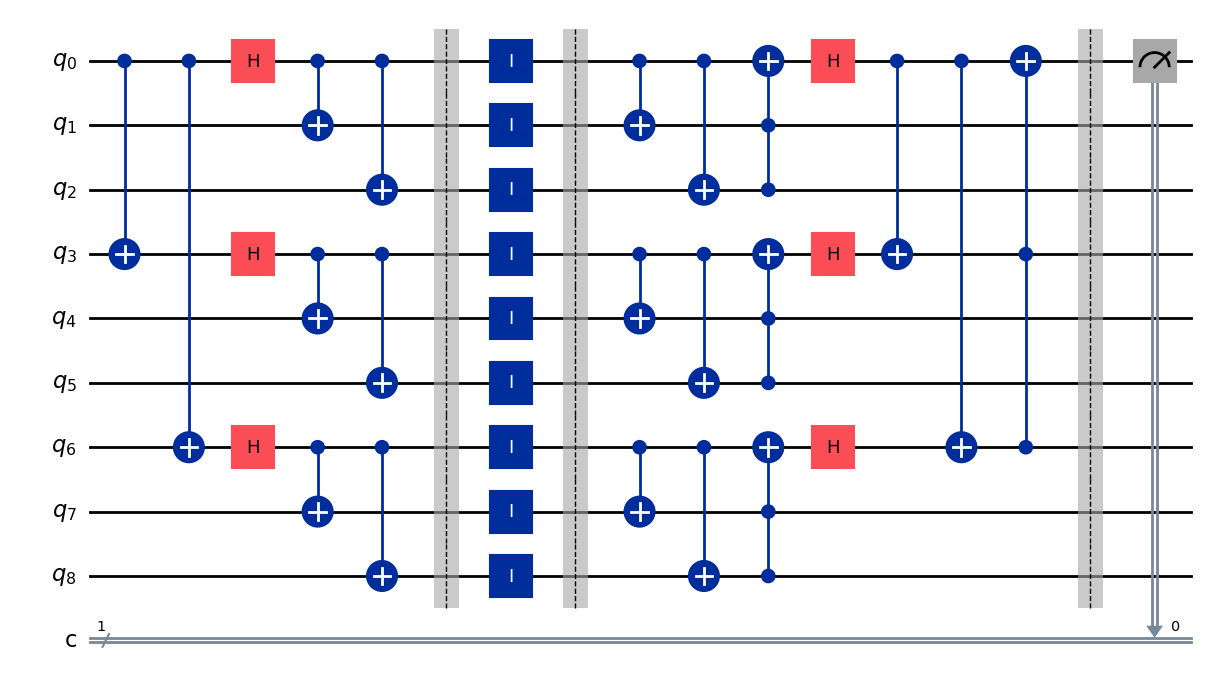

In [6]:
circuit.measure(0,0)
circuit.draw("mpl")

In [7]:
sim = AerSimulator()

compiled_circuit = transpile(circuit, sim, optimization_level=0)

job = sim.run(compiled_circuit, shots=1000, noise_model=model,basis_gates=model.basis_gates) 
result = job.result()

counts = result.get_counts(compiled_circuit)
print(counts)

{'1': 57, '0': 943}
